In [2]:
import pandas as pd

# Read each dataset
nykaa = pd.read_csv('nykaa_campaign_data_with_nulls.csv')
purplle = pd.read_csv('purplle_campaign_data_with_nulls.csv')
tira = pd.read_csv('tira_campaign_data_with_nulls.csv')

# Tag brand names
nykaa['Brand'] = 'Nykaa'
purplle['Brand'] = 'Purplle'
tira['Brand'] = 'Tira'

# Combine into a master dataset
all_campaigns_df = pd.concat(
    [nykaa, purplle, tira], ignore_index=True
)

print('Combined shape:', all_campaigns_df.shape)

Combined shape: (166665, 17)


In [ ]:
import numpy as np
import pandas as pd

# Remove duplicate records
all_campaigns_df = all_campaigns_df.drop_duplicates().reset_index(drop=True)

# Fill missing Campaign_IDs per Brand
brand_prefixes = {'Nykaa': 'NY', 'Purplle': 'PU', 'Tira': 'TI'}
seq_prefix = all_campaigns_df['Brand'].map(brand_prefixes).fillna('CMP')
seq_num = (1000 + all_campaigns_df.groupby('Brand').cumcount()).astype(str)
all_campaigns_df['Campaign_ID'] = all_campaigns_df['Campaign_ID'].fillna(
    seq_prefix + '-CMP-' + seq_num
)

# Fill Categorical Columns with Brand-level Mode
cat_cols = [
    'Campaign_Type',
    'Target_Audience',
    'Channel_Used',
    'Language',
    'Customer_Segment',
]
for col in cat_cols:
  all_campaigns_df[col] = all_campaigns_df.groupby('Brand')[col].transform(
      lambda s: s.fillna(s.mode()[0])
  )

# Fill Numerical Columns with Brand-level Median
num_cols = [
    'Duration',
    'Impressions',
    'Clicks',
    'Leads',
    'Conversions',
    'Revenue',
    'Acquisition_Cost',
    'Engagement_Score',
]
for col in num_cols:
  all_campaigns_df[col] = all_campaigns_df.groupby('Brand')[col].transform(
      lambda s: s.fillna(s.median())
  )

# Calculate and validate ROI using financial ground-truth formula
total_cost = (
    all_campaigns_df['Acquisition_Cost'] * all_campaigns_df['Conversions']
)
all_campaigns_df['ROI'] = np.where(total_cost > 0,((all_campaigns_df['Revenue'] - total_cost) / total_cost).round(2),0.0,)

# Fill Date column and parse to datetime format
all_campaigns_df['Date'] = (
    all_campaigns_df['Date'].ffill().bfill()
)  # or pd.to_datetime(...)
all_campaigns_df['Date'] = pd.to_datetime(
    all_campaigns_df['Date'], format='%d-%m-%Y', errors='coerce'
)

# Verify zero nulls remain
print('Remaining Null Count:')
print(all_campaigns_df.isnull().sum())

Remaining Null Count:
Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
Brand               0
dtype: int64


In [ ]:
# Apply multi-label one-hot encoding for the Channel_Used column
channel_one_hot = all_campaigns_df['Channel_Used'].str.get_dummies(
    sep=', '
).add_prefix('Channel_')

# Join the one-hot encoded columns back into the main DataFrame
all_campaigns_df = pd.concat([all_campaigns_df, channel_one_hot], axis=1)

# View the new one-hot encoded channel columns
print(all_campaigns_df[channel_one_hot.columns].head())

all_campaigns_df['Profit_Loss_Flag'] = np.where(all_campaigns_df['ROI'] > 0, 1, 0)

   Channel_Email  Channel_Facebook  Channel_Google  Channel_Instagram  \
0              0                 0               0                  0   
1              0                 0               0                  0   
2              0                 0               1                  0   
3              0                 1               0                  1   
4              0                 1               0                  1   

   Channel_WhatsApp  Channel_YouTube  
0                 1                1  
1                 0                1  
2                 1                1  
3                 0                1  
4                 0                0  


In [8]:
# all_campaigns_df.to_csv('all_campaign_data_cleaned.csv', index=False)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv('all_campaign_data_cleaned.csv')

# Parse Date into cyclical/calendar numeric features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Extract Channel columns
channel_cols = [
    'Channel_Email',
    'Channel_Facebook',
    'Channel_Google',
    'Channel_Instagram',
    'Channel_WhatsApp',
    'Channel_YouTube',
]

# One-Hot Encode all Categorical columns
cat_cols = [
    'Brand',
    'Campaign_Type',
    'Target_Audience',
    'Language',
    'Customer_Segment',
]
cat_dummies = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)

# Numerical columns (includes all performance, financial, engagement & flag metrics)
numeric_cols = [
    'Duration',
    'Impressions',
    'Clicks',
    'Leads',
    'Conversions',
    'Acquisition_Cost',
    'ROI',
    'Engagement_Score',
    'Profit_Loss_Flag',
    'Year',
    'Month',
    'Day',
    'DayOfWeek',
]

# Construct Feature Matrix (X) using ALL columns and Target (y)
X = pd.concat([df[numeric_cols + channel_cols], cat_dummies], axis=1)
y = df['Revenue']

# TRAIN-TEST SPLIT (80% Train, 20% Unseen Test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# TRAIN & EVALUATE HIST GRADIENT BOOSTING REGRESSOR

print("\nTraining Hist Gradient Boosting Regressor on all features...")

hgb_reg = HistGradientBoostingRegressor(
    max_iter=300,
    max_leaf_nodes=63,
    learning_rate=0.08,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42,
)

hgb_reg.fit(X_train, y_train)
y_pred = hgb_reg.predict(X_test)

# Compute Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

results_df = pd.DataFrame([{
    'Model': 'Hist Gradient Boosting Regressor (All Features)',
    'Features Count': X.shape[1],
    'R² Score': round(r2, 4),
    'MAE (₹)': round(mae, 2),
    'MSE': f"{mse:.2e}",
    'RMSE (₹)': round(rmse, 2),
}])

print("📈 REGRESSION MODEL EVALUATION (ALL DATASET FEATURES)")
display(results_df)


Training Hist Gradient Boosting Regressor on all features...
📈 REGRESSION MODEL EVALUATION (ALL DATASET FEATURES)


,Model,Features Count,R² Score,MAE (₹),MSE,RMSE (₹)
0,Hist Gradient Boosting Regressor (All Features),36,0.993,13301.56,1.60e+09,39938.65


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

df = pd.read_csv('all_campaign_data_cleaned.csv')

# Extract Calendar / Date features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Extract Channel columns
channel_cols = [
    'Channel_Email',
    'Channel_Facebook',
    'Channel_Google',
    'Channel_Instagram',
    'Channel_WhatsApp',
    'Channel_YouTube',
]

# One-Hot Encode all Categorical columns
cat_cols = [
    'Brand',
    'Campaign_Type',
    'Target_Audience',
    'Language',
    'Customer_Segment',
]
cat_dummies = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)

# Numerical columns: All dataset metrics INCLUDING Revenue, STRICTLY EXCLUDING ROI
numeric_cols = [
    'Duration',
    'Impressions',
    'Clicks',
    'Leads',
    'Conversions',
    'Revenue',
    'Acquisition_Cost',
    'Engagement_Score',
    'Year',
    'Month',
    'Day',
    'DayOfWeek',
]

# Construct Feature Matrix (X) and Target (y)
X = pd.concat([df[numeric_cols + channel_cols], cat_dummies], axis=1)
y = df['Profit_Loss_Flag']

# TRAIN-TEST SPLIT (80% Train, 20% Unseen Test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# TRAIN & EVALUATE XGBOOST CLASSIFIER

print('\nTraining XGBoost Classifier on all dataset features (without ROI)...')

xgb_cls = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

xgb_cls.fit(X_train, y_train)
y_pred = xgb_cls.predict(X_test)
y_prob = xgb_cls.predict_proba(X_test)[:, 1]

# Compute Classification Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

cls_results_df = pd.DataFrame([{
    'Model': 'XGBoost Classifier (All Features, Excl. ROI)',
    'Features Count': X.shape[1],
    'Accuracy': round(acc, 4),
    'Precision': round(prec, 4),
    'Recall': round(rec, 4),
    'F1-Score': round(f1, 4),
    'ROC-AUC': round(roc_auc, 4),
}])

print('CLASSIFICATION EVALUATION RESULTS (PROFIT / LOSS PREDICTION)')

display(cls_results_df)

print('\n--- DETAILED CLASSIFICATION REPORT ---')
print(
    classification_report(
        y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']
    )
)


Training XGBoost Classifier on all dataset features (without ROI)...
CLASSIFICATION EVALUATION RESULTS (PROFIT / LOSS PREDICTION)


,Model,Features Count,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,"XGBoost Classifier (All Features, Excl. ROI)",35,0.9944,0.996,0.9967,0.9964,0.9998



--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Loss (0)       0.99      0.99      0.99      7454
  Profit (1)       1.00      1.00      1.00     25879

    accuracy                           0.99     33333
   macro avg       0.99      0.99      0.99     33333
weighted avg       0.99      0.99      0.99     33333



In [11]:
# EXPLORATORY DATA ANALYSIS (EDA) - SUMMARY METRICS

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure derived metrics exist
if 'Total_Cost' not in all_campaigns_df.columns:
  all_campaigns_df['Total_Cost'] = (
      all_campaigns_df['Acquisition_Cost'] * all_campaigns_df['Conversions']
  )
if 'Profit' not in all_campaigns_df.columns:
  all_campaigns_df['Profit'] = (
      all_campaigns_df['Revenue'] - all_campaigns_df['Total_Cost']
  )
if 'CTR' not in all_campaigns_df.columns:
  all_campaigns_df['CTR'] = (
      all_campaigns_df['Clicks'] / all_campaigns_df['Impressions']
  ) * 100
if 'Conversion_Rate' not in all_campaigns_df.columns:
  all_campaigns_df['Conversion_Rate'] = (
      all_campaigns_df['Conversions'] / all_campaigns_df['Clicks']
  ) * 100

# --- A. Brand Performance Summary ---
brand_summary = (
    all_campaigns_df.groupby('Brand')
    .agg(
        Total_Campaigns=('Campaign_ID', 'count'),
        Total_Revenue=('Revenue', 'sum'),
        Total_Spend=('Total_Cost', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Avg_ROI=('ROI', 'mean'),
        Median_ROI=('ROI', 'median'),
        Avg_CTR=('CTR', 'mean'),
        Avg_CVR=('Conversion_Rate', 'mean'),
        Avg_CAC=('Acquisition_Cost', 'mean'),
    )
    .reset_index()
)

print('--- BRAND PERFORMANCE SUMMARY ---')
display(brand_summary.round(2))

# --- B. Top 3 & Bottom 3 Campaigns by ROI ---
top_campaigns = all_campaigns_df[
    [
        'Campaign_ID',
        'Brand',
        'Campaign_Type',
        'Channel_Used',
        'Revenue',
        'Total_Cost',
        'ROI',
        'Profit',
    ]
].sort_values(by='ROI', ascending=False)

print('\n--- TOP 3 CAMPAIGNS (HIGHEST ROI) ---')
display(top_campaigns.head(3))

print('\n--- BOTTOM 3 CAMPAIGNS (LOWEST ROI / LOSS) ---')
display(top_campaigns.tail(3))

# --- C. Channel-wise Effectiveness Summary ---
channel_df = all_campaigns_df.dropna(subset=['Channel_Used']).copy()
channel_df['Channel_List'] = channel_df['Channel_Used'].str.split(', ')
channel_exploded = channel_df.explode('Channel_List')

channel_summary = (
    channel_exploded.groupby('Channel_List')
    .agg(
        Campaign_Count=('Campaign_ID', 'count'),
        Total_Revenue=('Revenue', 'sum'),
        Total_Spend=('Total_Cost', 'sum'),
        Avg_ROI=('ROI', 'mean'),
        Avg_CTR=('CTR', 'mean'),
        Avg_CVR=('Conversion_Rate', 'mean'),
        Avg_Engagement=('Engagement_Score', 'mean'),
    )
    .reset_index()
    .rename(columns={'Channel_List': 'Channel'})
    .sort_values(by='Avg_ROI', ascending=False)
)

print('\n--- CHANNEL EFFECTIVENESS SUMMARY ---')
display(channel_summary.round(2))

--- BRAND PERFORMANCE SUMMARY ---


,Brand,Total_Campaigns,Total_Revenue,Total_Spend,Total_Profit,Avg_ROI,Median_ROI,Avg_CTR,Avg_CVR,Avg_CAC
0,Nykaa,55555,2.820985e+10,1.013013e+10,1.807972e+10,2.79,1.24,8.57,22.57,368.96
1,Purplle,55555,2.810111e+10,1.008673e+10,1.801439e+10,2.77,1.23,8.56,22.46,369.83
2,Tira,55555,2.803968e+10,1.010647e+10,1.793321e+10,2.78,1.24,8.57,22.49,366.99



--- TOP 3 CAMPAIGNS (HIGHEST ROI) ---


,Campaign_ID,Brand,Campaign_Type,Channel_Used,Revenue,Total_Cost,ROI,Profit
151837,TI-CMP-41727,Tira,Influencer,Instagram,3211168.0,10501.25,304.79,3200666.75
163830,TI-CMP-53720,Tira,Email,Google,2940930.0,10408.25,281.56,2930521.75
157981,TI-CMP-47871,Tira,Paid Ads,"Instagram, Facebook",2546437.0,10431.50,243.11,2536005.50



--- BOTTOM 3 CAMPAIGNS (LOWEST ROI / LOSS) ---


,Campaign_ID,Brand,Campaign_Type,Channel_Used,Revenue,Total_Cost,ROI,Profit
302,NY-CMP-1302,Nykaa,Influencer,YouTube,16944.0,7367527.74,-1.0,-7350583.74
33324,NY-CMP-34324,Nykaa,Paid Ads,Instagram,14079.0,12038118.48,-1.0,-12024039.48
143476,TI-CMP-33366,Tira,Influencer,Facebook,14210.0,3356478.50,-1.0,-3342268.50



--- CHANNEL EFFECTIVENESS SUMMARY ---


,Channel,Campaign_Count,Total_Revenue,Total_Spend,Avg_ROI,Avg_CTR,Avg_CVR,Avg_Engagement
3,Instagram,55695,2.835146e+10,1.014593e+10,2.82,8.59,22.58,13.79
0,Email,58325,2.963509e+10,1.058451e+10,2.81,8.59,22.56,13.81
2,Google,52831,2.669849e+10,9.589926e+09,2.78,8.54,22.54,13.71
1,Facebook,52814,2.673481e+10,9.639111e+09,2.76,8.55,22.54,13.72
4,WhatsApp,52724,2.666470e+10,9.601039e+09,2.75,8.59,22.51,13.80
5,YouTube,52781,2.660654e+10,9.613893e+09,2.75,8.55,22.44,13.71


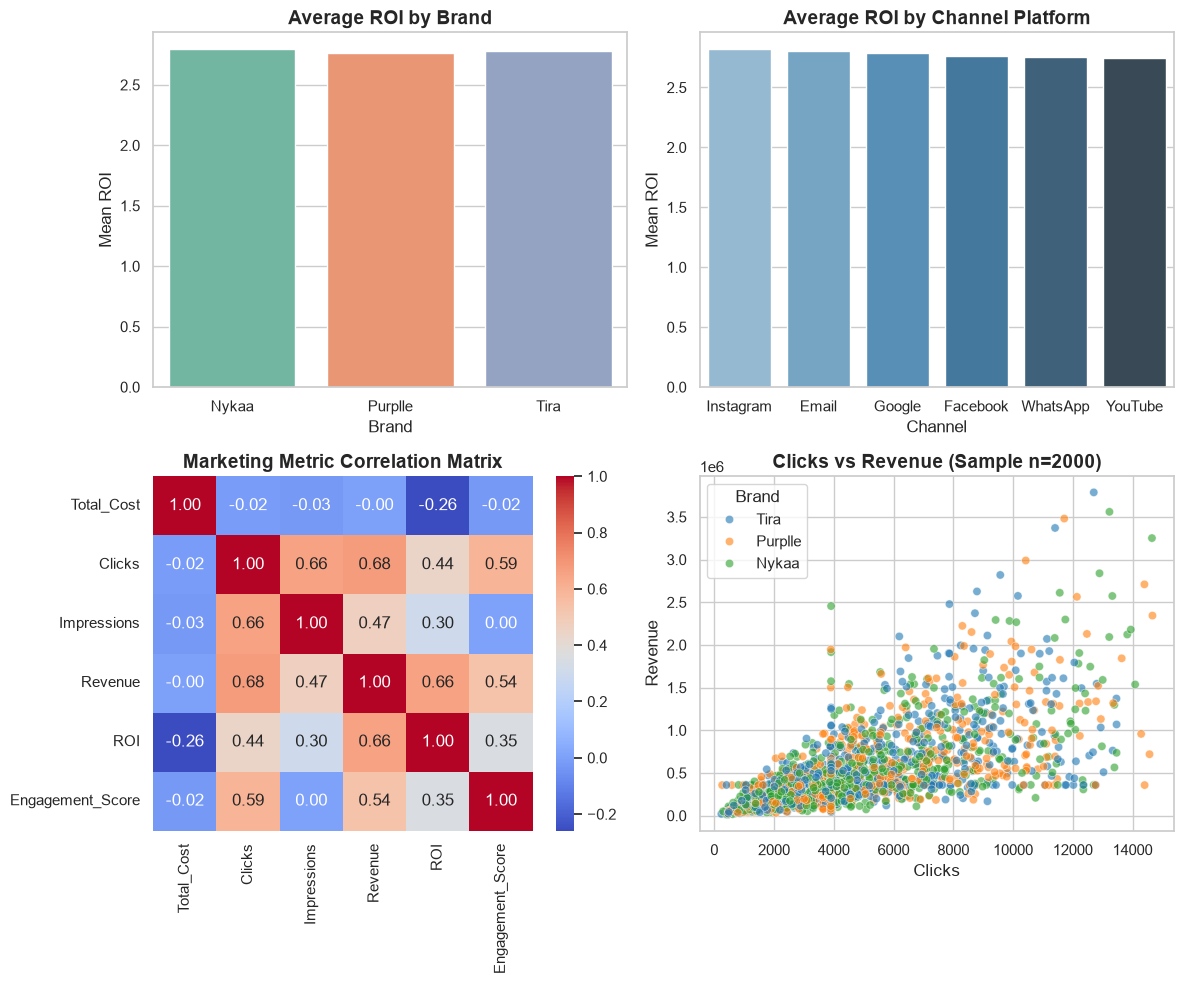

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Compute summary tables needed for the plots
if 'Total_Cost' not in all_campaigns_df.columns:
  all_campaigns_df['Total_Cost'] = (
      all_campaigns_df['Acquisition_Cost'] * all_campaigns_df['Conversions']
  )

# Brand Performance Summary
brand_summary = (
    all_campaigns_df.groupby('Brand')
    .agg(
        Total_Campaigns=('Campaign_ID', 'count'),
        Total_Revenue=('Revenue', 'sum'),
        Total_Spend=('Total_Cost', 'sum'),
        Avg_ROI=('ROI', 'mean'),
    )
    .reset_index()
)

# Channel Effectiveness Summary
channel_df = all_campaigns_df.dropna(subset=['Channel_Used']).copy()
channel_df['Channel_List'] = channel_df['Channel_Used'].str.split(', ')
channel_exploded = channel_df.explode('Channel_List')
channel_summary = (
    channel_exploded.groupby('Channel_List')
    .agg(Avg_ROI=('ROI', 'mean'))
    .reset_index()
    .rename(columns={'Channel_List': 'Channel'})
    .sort_values(by='Avg_ROI', ascending=False)
)

# 2. Generate EDA Visualizations
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Brand vs Avg ROI
sns.barplot(
    data=brand_summary,
    x='Brand',
    y='Avg_ROI',
    palette='Set2',
    ax=axes[0, 0],
    hue='Brand',
    legend=False,
)
axes[0, 0].set_title('Average ROI by Brand', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Mean ROI')

# Plot 2: Channel ROI Comparison
sns.barplot(
    data=channel_summary,
    x='Channel',
    y='Avg_ROI',
    palette='Blues_d',
    ax=axes[0, 1],
    hue='Channel',
    legend=False,
)
axes[0, 1].set_title(
    'Average ROI by Channel Platform', fontsize=14, fontweight='bold'
)
axes[0, 1].set_ylabel('Mean ROI')

# Plot 3: Correlation Heatmap
corr_cols = [
    'Total_Cost',
    'Clicks',
    'Impressions',
    'Revenue',
    'ROI',
    'Engagement_Score',
]
sns.heatmap(
    all_campaigns_df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[1, 0],
    cbar=True,
)
axes[1, 0].set_title(
    'Marketing Metric Correlation Matrix', fontsize=14, fontweight='bold'
)

# Plot 4: Clicks vs. Revenue Scatter Sample
sample_df = all_campaigns_df.sample(n=2000, random_state=42)
sns.scatterplot(
    data=sample_df,
    x='Clicks',
    y='Revenue',
    hue='Brand',
    alpha=0.6,
    palette='tab10',
    ax=axes[1, 1],
)
axes[1, 1].set_title(
    'Clicks vs Revenue (Sample n=2000)', fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.show()